In [1]:
import os
import rasterio
import rioxarray as rxr
from matplotlib.pyplot import savefig
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import glob
from pathlib import Path
from rasterio.warp import reproject, Resampling
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from rasterstats import zonal_stats
import geopandas as gpd
from metloom.pointdata import SnotelPointData
from datetime import datetime
from osgeo import gdal
from shapely.geometry import Point
from pyproj import Proj, Transformer
gdal.UseExceptions()
from matplotlib.ticker import MaxNLocator
from scipy.stats import kruskal
import scikit_posthocs as sp

import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [18]:
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)

In [33]:
task1

{'20230405': {'SNODAS-basin': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_basin_clip.tif',
  'SNODAS-MCS': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\modeled/SNODAS\\SNODAS_20230405_MCS_clip.tif',
  'lidar': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\LiDAR_MCS_clip.tif',
  'basin_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_EB_basin_clip.tif',
   'HMS-TI': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\HMS_TI_basin_clip.tif',
   'iSnobal': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\iSnobal_basin_clip.tif',
   'SnowModel': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/task1/rasters\\SnowModel_basin_clip.tif'},
  'lidar_clip': {'HMS-EB': 'C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\\20230405\\outputs/t

In [41]:
dfs = []

for key in task1.keys():
    task1_clip = task1[key]['lidar_clip']
    task2_clip = task2[key]['lidar_clip']

    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip, }

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    data = src.read(1)
                    mask = (data == -9999)
                    data_masked = np.ma.array(data, mask=mask)
                    flattened = data_masked.compressed()
                    flattened = flattened[flattened < 5]
                    
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    })
                    dfs.append(df)


lidar_domain = pd.concat(dfs, ignore_index=True)    

In [42]:
Task1_lidar = lidar_domain[lidar_domain['Task'] =='Task 1']
Task2_lidar = lidar_domain[lidar_domain['Task'] =='Task 2']

C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_32964\654027597.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])


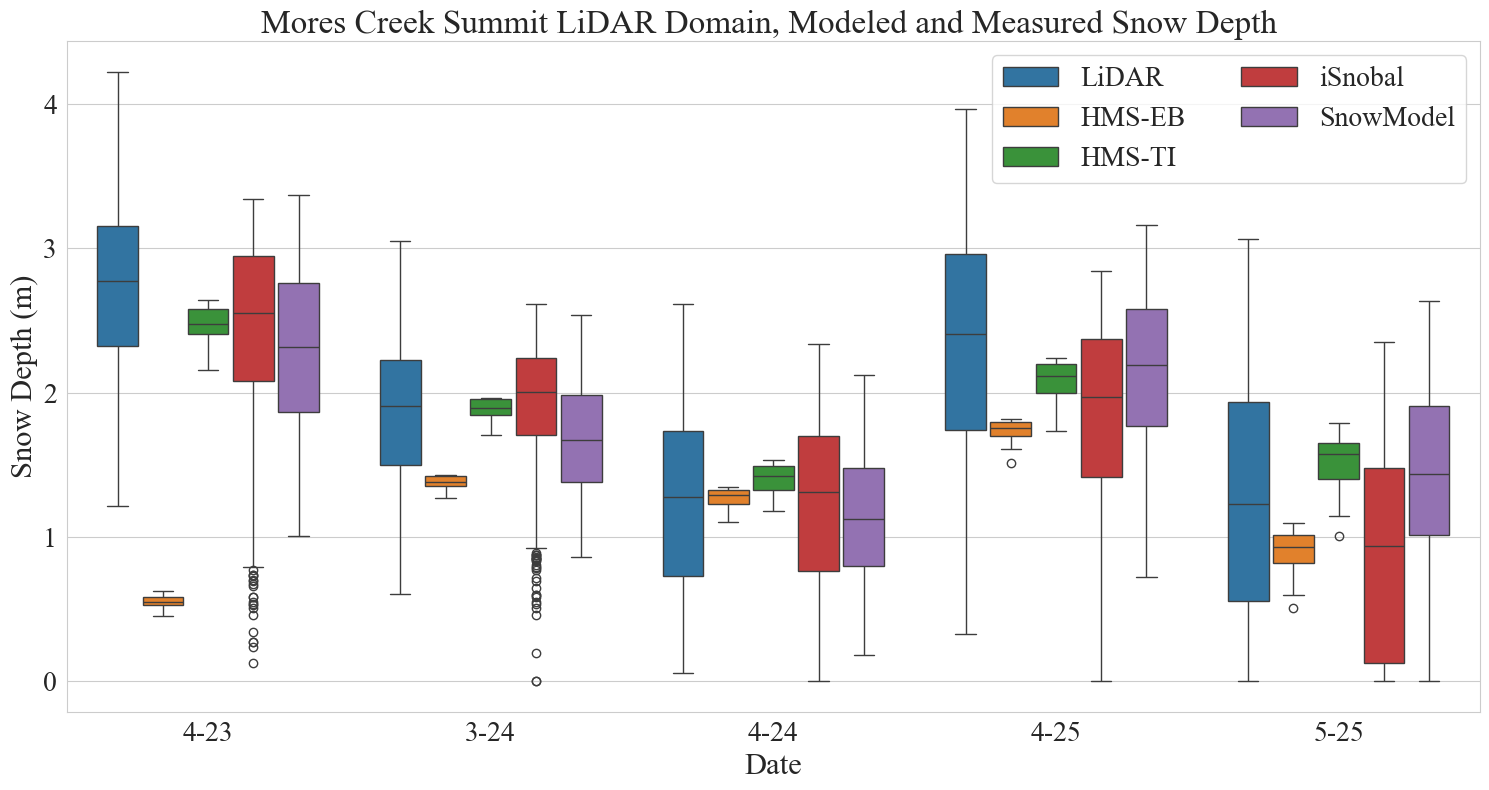

In [43]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))

order = ['LiDAR', 'HMS-EB', 'HMS-TI', 'iSnobal', 'SnowModel']

sns.boxplot(
    data=Task1_lidar,
    x = "Date",
    y= "Snow Depth",
    hue = "Model",
    hue_order = order,
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 22)
ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
ax.legend(prop={'size': 20}, ncol = 2) # Sets exact font size
ax.set_title("Mores Creek Summit LiDAR Domain, Modeled and Measured Snow Depth ", fontsize=24)



plt.tight_layout()

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/lidar_distributions.png", dpi = 300)
plt.show() 

In [91]:
dfs_resample = []

for key in task1.keys():
    task1_clip = task1[key]['resample']
    task2_clip = task2[key]['resample']
    lidar = task1[key]['lidar']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip, "Lidar": {"lidar": lidar}                                           #"lidar":lidar
           }

    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    data = src.read(1)
                    mask = (data == -9999)
                    data_masked = np.ma.array(data, mask=mask)
                    flattened = data_masked.compressed()
                    flattened = flattened[flattened < 5]
                    
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    })
                    dfs_resample.append(df)


dfs_resample = pd.concat(dfs_resample, ignore_index=True)    

In [96]:
Task1_resample = dfs_resample[(dfs_resample['Task'] =='Task 1') |(dfs_resample['Task'] == 'Lidar')  ]

In [97]:
print(Task1_resample['Model'].unique())


['HMS-Energy-Balance' 'HMS-Temperature-Index' 'iSnobal' 'SnowModel'
 'lidar']


In [98]:
df_filtered = Task1_resample[
    (Task1_resample['Model'] == 'iSnobal') |
    (Task1_resample['Model'] == 'SnowModel') |
    (Task1_resample['Model'] == 'lidar')
]

In [99]:
print(df_filtered['Model'].unique())

['iSnobal' 'SnowModel' 'lidar']


In [100]:
counts = (
    df_filtered
    .groupby(['Date', 'Model'])
    .size()
    .unstack(fill_value=0)
)

print(counts)

Model     SnowModel  iSnobal  lidar
Date                               
20230405       2732     2792   2801
20240315       2696     2715   2726
20240418       2519     2544   2545
20250404       2596     2632   2633
20250501       2698     2728   2731


In [104]:
from scipy.stats import kruskal

for date in df_filtered['Date'].unique():

    subset = df_filtered[df_filtered['Date'] == date]

    lidar_vals = subset[subset['Model'] == 'lidar']['Snow Depth']
    snowmodel_vals = subset[subset['Model'] == 'SnowModel']['Snow Depth']
    isnobal_vals = subset[subset['Model'] == 'iSnobal']['Snow Depth']

    stat, p = kruskal(lidar_vals, snowmodel_vals, isnobal_vals)

    print(f"\nDate: {date}")
    print(f"H-statistic: {stat:.3f}")
    print(f"P-value: {p:.5f}")


Date: 20230405
H-statistic: 766.385
P-value: 0.00000

Date: 20240315
H-statistic: 690.613
P-value: 0.00000

Date: 20240418
H-statistic: 62.373
P-value: 0.00000

Date: 20250404
H-statistic: 596.773
P-value: 0.00000

Date: 20250501
H-statistic: 798.342
P-value: 0.00000


In [106]:
import scikit_posthocs as sp

results = {}

for date in df_filtered['Date'].unique():

    subset = df_filtered[df_filtered['Date'] == date]

    posthoc = sp.posthoc_dunn(
        subset,
        val_col='Snow Depth',
        group_col='Model',
        p_adjust='bonferroni'   # or 'fdr_bh'
    )

    results[date] = posthoc

    print(posthoc)

               SnowModel       iSnobal          lidar
SnowModel   1.000000e+00  1.578642e-39  4.849261e-168
iSnobal     1.578642e-39  1.000000e+00   3.643994e-47
lidar      4.849261e-168  3.643994e-47   1.000000e+00
               SnowModel        iSnobal         lidar
SnowModel   1.000000e+00  2.423448e-149  7.207161e-57
iSnobal    2.423448e-149   1.000000e+00  9.637587e-24
lidar       7.207161e-57   9.637587e-24  1.000000e+00
              SnowModel       iSnobal         lidar
SnowModel  1.000000e+00  5.124119e-14  1.281547e-07
iSnobal    5.124119e-14  1.000000e+00  8.388008e-02
lidar      1.281547e-07  8.388008e-02  1.000000e+00
              SnowModel        iSnobal          lidar
SnowModel  1.000000e+00   4.708397e-57   7.742211e-15
iSnobal    4.708397e-57   1.000000e+00  1.314030e-126
lidar      7.742211e-15  1.314030e-126   1.000000e+00
               SnowModel        iSnobal         lidar
SnowModel   1.000000e+00  1.859399e-172  6.374041e-28
iSnobal    1.859399e-172   1.000000e